In [2]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

In [3]:
df_agn = load_quasar_data("data/july21_chisq2_hostpl_N20w4000s200/july21_chisq2_hostpl_N20w4000s200_fits_job0.h5", populate_sdss=False)

print(list(df_agn.keys()))


Reading quasars from HDF5: 100%|██████████| 18/18 [00:00<00:00, 246.47it/s]

Number of quasars loaded: 18
Columns with NaNs: []
Before dropping NaNs and infs, number of quasars: 18
Number of quasars with 0 < z <= 0.5: 0
Number of quasars with z > 3: 0
Before data cuts, number of quasars: 18
Number of quasars with 0 < z <= 0.5: 0
Number of quasars with z > 3: 0
Number of quasars with 0 < z <= 0.5: 0
Number of dropped quasars with 0 < z <= 0.5: 0
Number of quasars with z > 3: 0
Final number of quasars: 18
['object_id', 'EXTINCTION', 'FHOST_5100', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'LOGLBOL', 'M_i', 'alpha_host', 'alpha_host_err', 'apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'bwb_alpha', 'bwb_alpha_err', 'bwb_beta', 'bwb_beta_err', 'clean_bands', 'color', 'ebv', 'eta_A1', 'eta_A1_err', 'eta_A2', 'eta_A2_err',

In [4]:
df_agn

,object_id,EXTINCTION,FHOST_5100,LOGL1350,LOGL1350_ERR,LOGL1700,LOGL1700_ERR,LOGL2500,LOGL2500_ERR,LOGL3000,...,sdss_name,sn_median_all,z,chi_sq,alpha_nu,alpha_nu_err,MY_LOGL2500,MY_LOGL2500_ERR,apparent_mag_2500,apparent_mag_2500_err
0,1390639,0.055888,0.0,0.000000,-1.000000,45.147563,0.010319,45.025989,0.003999,45.010309,...,024333.19-002652.8,5.122865,1.415335,72.909117,-0.5,0.1,45.036190,0.003169,22.717706,0.009996
1,1391164,0.054812,0.0,0.000000,-1.000000,45.137657,0.006880,45.058362,0.004635,45.027444,...,024212.65-010339.5,5.905488,1.441615,46.393180,-0.5,0.1,45.059898,0.003237,22.697875,0.011587
2,1391283,0.056664,0.0,46.314478,0.001538,45.999097,0.002673,45.452200,0.010755,45.439488,...,024154.42-004757.6,8.387513,2.393872,13.272702,-0.5,0.1,46.104349,0.001322,23.421603,0.026887
3,1394504,0.049027,0.0,0.000000,-1.000000,0.000000,-1.000000,44.599740,0.006339,44.570434,...,023237.27-010122.2,3.772825,0.973809,20.980897,-0.5,0.1,44.603815,0.004961,22.559896,0.015848
4,1396018,0.054133,0.0,0.000000,-1.000000,0.000000,-1.000000,44.801305,0.004176,44.766056,...,022837.06-001005.1,6.203355,0.754966,90.117475,-0.5,0.1,44.802384,0.002969,21.247403,0.010441
5,1402045,0.063406,0.0,0.000000,-1.000000,45.287753,0.025026,45.258453,0.010435,45.189353,...,021220.61-004715.9,3.079415,1.487208,88.344890,-0.5,0.1,45.240399,0.007039,22.301223,0.026088
6,1411612,0.044003,0.0,0.000000,-1.000000,44.807746,0.009273,44.580703,0.007797,44.581233,...,014328.80-001433.7,4.324597,1.144166,34.475878,-0.5,0.1,44.634684,0.005066,23.130370,0.019493
7,1412877,0.056223,0.0,0.000000,-1.000000,45.480133,0.001998,45.507225,0.001710,45.435276,...,014004.34+010001.9,12.493773,1.487706,532.476467,-0.5,0.1,45.462764,0.001187,21.680407,0.004276
8,1414251,0.052573,0.0,0.000000,-1.000000,0.000000,-1.000000,45.714561,0.002260,45.738845,...,013555.89+004016.8,30.339111,0.908097,1530.875583,-0.5,0.1,45.762732,0.001129,19.548723,0.005649
9,1415162,0.048244,0.0,46.143742,0.002062,46.090024,0.001805,46.020730,0.004802,46.024042,...,013332.87+002438.3,13.050286,2.278728,217.915050,-0.5,0.1,46.010714,0.001284,21.832563,0.012006


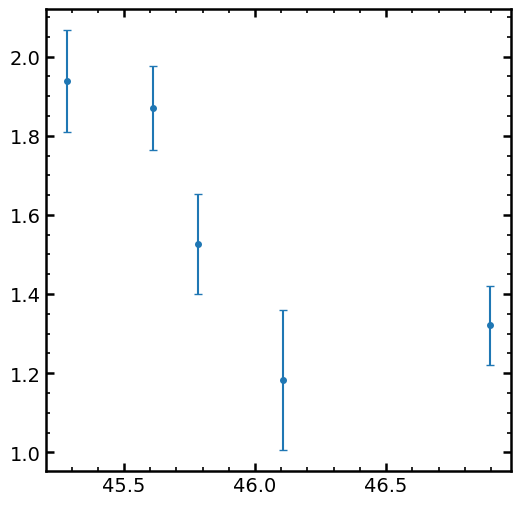

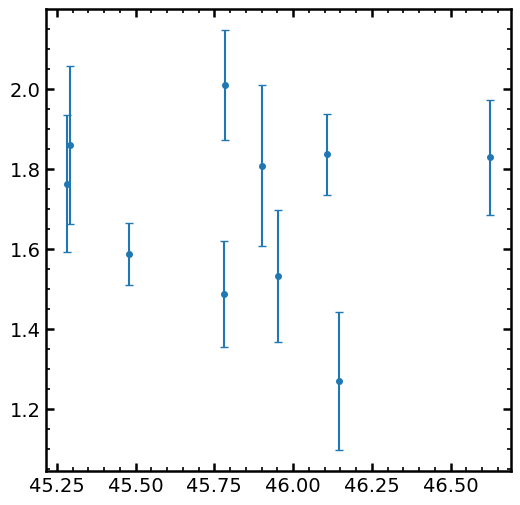

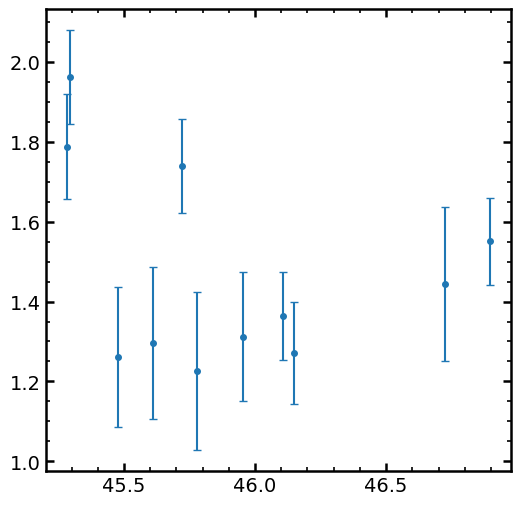

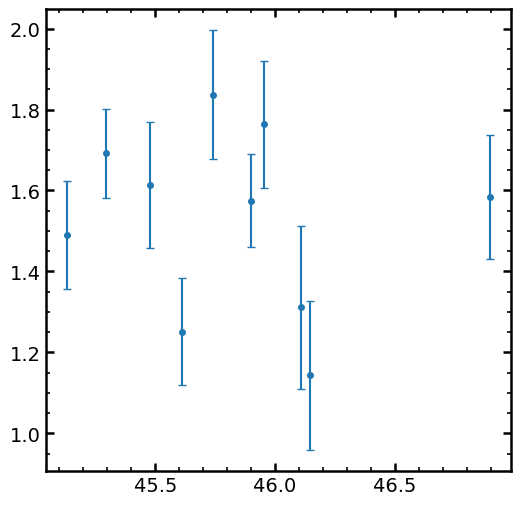

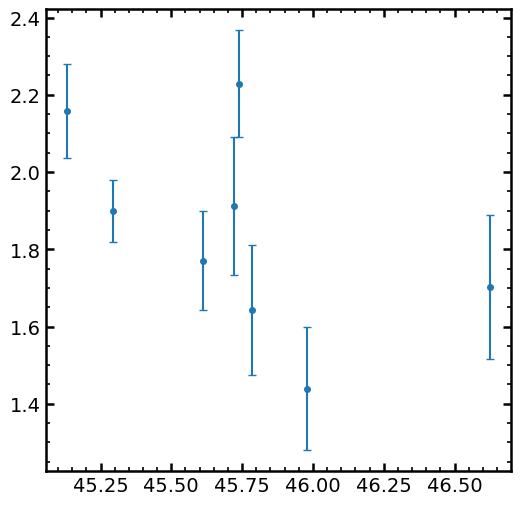

In [27]:
for b in ['u', 'g', 'r', 'i', 'z']:
    mask = df_agn[f'log_lag_blr_{b}_err'] < 0.5
    z = df_agn['z']
    plt.errorbar(df_agn['LOGLBOL'][mask], df_agn[f'log_lag_blr_{b}'][mask]/np.log(10) - np.log10(1 + z[mask]),
    yerr=df_agn[f'log_lag_blr_{b}_err'][mask]/np.log(10), linestyle='none', marker='o')
    plt.show()

In [6]:
list(df_agn.keys())

['object_id',
 'EXTINCTION',
 'FHOST_5100',
 'LOGL1350',
 'LOGL1350_ERR',
 'LOGL1700',
 'LOGL1700_ERR',
 'LOGL2500',
 'LOGL2500_ERR',
 'LOGL3000',
 'LOGL3000_ERR',
 'LOGL5100',
 'LOGL5100_ERR',
 'LOGLBOL',
 'M_i',
 'alpha_host',
 'alpha_host_err',
 'apparent_mag_g',
 'apparent_mag_g_err',
 'apparent_mag_i',
 'apparent_mag_i_err',
 'apparent_mag_r',
 'apparent_mag_r_err',
 'apparent_mag_u',
 'apparent_mag_u_err',
 'apparent_mag_z',
 'apparent_mag_z_err',
 'bwb_alpha',
 'bwb_alpha_err',
 'bwb_beta',
 'bwb_beta_err',
 'clean_bands',
 'color',
 'ebv',
 'eta_A1',
 'eta_A1_err',
 'eta_A2',
 'eta_A2_err',
 'eta_break',
 'eta_break_err',
 'eta_tau1',
 'eta_tau1_err',
 'eta_tau2',
 'eta_tau2_err',
 'f_host',
 'f_host_err',
 'fhost',
 'lag0',
 'lag0_err',
 'lag_beta',
 'lag_beta_err',
 'log_amp_delta_blr_g',
 'log_amp_delta_blr_g_err',
 'log_amp_delta_blr_i',
 'log_amp_delta_blr_i_err',
 'log_amp_delta_blr_r',
 'log_amp_delta_blr_r_err',
 'log_amp_delta_blr_u',
 'log_amp_delta_blr_u_err',
 'log_